# Lecture 4 - (11/06/2026)

Today's Topics:

- Linear Modeling
- Scikit Learn
- Multiple Linear Regression
- Gradient Descent
- Feature Engineering

## Linear Modeling

We can score each line with how close the actual and predicted y-values are, using RMSE for the loss function.

The line with the best score is determined as the regression line.

We can visualize this process [here](https://setosa.io/ev/ordinary-least-squares-regression/)

Our goal in linear regression is to seek the line $y=mx+b$ that minimizes the least square errors

That is to say, the line that minimizes the mean of the MSE(mean squared errors) for all lines.

When x and y are in standard units, regression line is:

$$ y = r*x + 0$$

Modeling should generally consist of three main steps

- Select a model (in our case linear regression)
- Select a loss function (in our case RMSE)
- Minimize the loss function

We also need to prep our data for prediction, adding in those steps:

- Split your data into pieces for training & validation.
- Select a model (in our case linear regression)
- Select a loss function (in our case RMSE)
- Minimize the loss function, using the training data
- Validate your model with the reserved test data

## Scikit Learn

![image](https://scikit-learn.org/stable/_static/scikit-learn-logo-without-subtitle.svg)

[Scikit learn](https://scikit-learn.org/stable/index.html) is:
- Toolkit for predictive data analysis.
- Built on NumPy, SciPy, and matplotlib
- Open source, commercially usable (BSD license)
- Easy ‘building blocks’ for analysis, many tutorials & recipes

In [ ]:
!pip install scikit-learn  # to install

In [ ]:
def matprint(mat, fmt="g"):
    col_maxes = [max([len(("{:"+fmt+"}").format(x)) for x in col]) for col in mat.T]
    for x in mat:
        for i, y in enumerate(x):
            print(("{:"+str(col_maxes[i])+fmt+"}").format(y), end="  ")
        print("")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model, datasets
from sklearn.model_selection import train_test_split

In [ ]:
X,y = datasets.load_diabetes(return_X_y=True)

matprint(X[:20])

  0.0380759   0.0506801    0.0616962    0.0218724   -0.0442235    -0.0348208   -0.0434008  -0.00259226   0.0199075   -0.0176461  
-0.00188202  -0.0446416   -0.0514741   -0.0263275  -0.00844872    -0.0191633    0.0744116   -0.0394934  -0.0683315    -0.092204  
  0.0852989   0.0506801    0.0444512  -0.00567042   -0.0455995    -0.0341945   -0.0323559  -0.00259226  0.00286131   -0.0259303  
 -0.0890629  -0.0446416    -0.011595   -0.0366561    0.0121906     0.0249906   -0.0360376    0.0343089   0.0226877  -0.00936191  
 0.00538306  -0.0446416   -0.0363847    0.0218724   0.00393485     0.0155961   0.00814208  -0.00259226  -0.0319876   -0.0466409  
 -0.0926955  -0.0446416   -0.0406959   -0.0194418   -0.0689906    -0.0792878    0.0412768   -0.0763945  -0.0411762   -0.0963462  
 -0.0454725   0.0506801   -0.0471628    -0.015999   -0.0400956       -0.0248  0.000778808   -0.0394934  -0.0629169   -0.0383567  
  0.0635037   0.0506801  -0.00189471    0.0666294    0.0906199      0.108914    0.0228686 

In [ ]:
y[:20]

array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
        69., 179., 185., 118., 171., 166., 144.,  97., 168.])

In [ ]:
X.shape, y.shape

((442, 10), (442,))

In [ ]:
# split the data into a training and validation set

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.33,random_state=42)

In [ ]:
X_train.shape, y_train.shape

((296, 10), (296,))

In [ ]:
X_test.shape, y_test.shape

((146, 10), (146,))

In [ ]:
# select a model

reg = linear_model.LinearRegression()

In [ ]:
# select a loss functon (defaults to RMSE)

# minimize the loss function using the training data
reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
# validate the model with the reserved test data
y_pred = reg.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"Mean squared error: {mean_squared_error(y_test, y_pred):.2f}")
print(f"Coefficient of determination: {r2_score(y_test, y_pred):.2f}")

Mean squared error: 2817.81
Coefficient of determination: 0.51


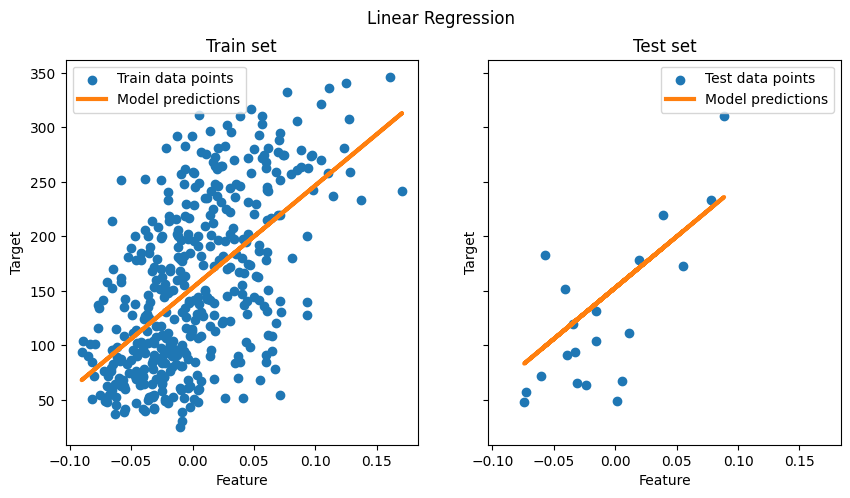

In [ ]:
# visualisation

X, y = datasets.load_diabetes(return_X_y=True)
X = X[:, [2]]  # Use only one feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=20, shuffle=False)
regressor = linear_model.LinearRegression().fit(X_train, y_train)

fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

ax[0].scatter(X_train, y_train, label="Train data points")
ax[0].plot(
    X_train,
    regressor.predict(X_train),
    linewidth=3,
    color="tab:orange",
    label="Model predictions",
)
ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
ax[0].legend()

ax[1].scatter(X_test, y_test, label="Test data points")
ax[1].plot(X_test, regressor.predict(X_test), linewidth=3, color="tab:orange", label="Model predictions")
ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
ax[1].legend()

fig.suptitle("Linear Regression")

plt.show()

Loss function Properties:
- Seeking the minimum of the loss function over the inputs
- Nice way to find minimums of functions is via calculus.
  - Take the derivatives and look at the 0's
- With the absolute values, MAE is not differentiable.
  - Limits are different from left and right
- MAE is minimal at the median of y, $\theta = median(y)$.
- MSE is the sum of quadratics, so, differentiable, and is minimal at the mean of y, $\theta=mean(y)$

![image](https://media.geeksforgeeks.org/wp-content/uploads/20220617000303/lossfunctions-660x495.png)

Huber combined good properties of both.

Mean Squared Error

$$\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n} (y_i - \theta)^2$$

Root Mean Squared Error

$$ \mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \theta)^2}$$

Mean Absolute Error

$$\mathrm{MAE} = \frac{1}{n}\sum_{i=1}^{n} \lvert y_i - \theta \rvert$$

## Multiple Linear Regression

### Linear Algebra

So far we have worked with 1-D linear regression where each observation has only one feature which allows us to use simple pointwise multiplication for each operation.

$$
y_i
=
\beta_0
+
\beta_1 x_{i_1}
+
\beta_2 x_{i_2}
+
\cdots
+
\beta_n x_{i_n}
+
\varepsilon_i
$$

which can also be represented as

$$ 
y_i=\begin{bmatrix} 1 & x_{i_1} & x_{i_2} & \cdots & x_{i_n}
\end{bmatrix}
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_n
\end{bmatrix}
+
\varepsilon_i
$$

Since we are working with dataframes that have multiple features, we will need to introduce something a little bit more powerful for our linear regression, matrices:

$$
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_m
\end{bmatrix}
=
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1n} \\
1 & x_{21} & x_{22} & \cdots & x_{2n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_n
\end{bmatrix}
+
\begin{bmatrix}
\varepsilon_1 \\
\varepsilon_2 \\
\vdots \\
\varepsilon_m
\end{bmatrix}
$$

Despite the change in notation, they behave the same way, and we can simplify this by writing:

$$
\hat y = wx + b
$$

### Feature Selection

In many data sets there may be several predictor variables that have an effect on a response variable. In fact, the interaction *between* variables may also be used to predict response. When we incorporate these additional predictor variables into the analysis, the model is called multiple linear regression.

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn import linear_model

In [ ]:
cali = datasets.fetch_california_housing()
X = pd.DataFrame(cali.data, columns=cali.feature_names)
y = pd.Series(cali.target)

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
dtype: float64

In [ ]:
X.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


For each row of X and y it can be interpreted as:


Entry 0 of X:
- Median Income: $83,252
- Age of Household: 41 years
- Average Rooms: 6.98
- Aveage Bedrooms: 1.02
- Population: 322
- Average Occupiants: 2.55 persons
- Latitude: 37.88
- Longitude: -122.23

Entry 0 of y:
- House Price: $452,600

What features in X do you think contribute to the value of y?

Let's guess that age of the house, number of rooms, and number of bedrooms all contribute to it.

Our new linear regression function will be:

$$ PRICE = \beta_0 + \beta_1 * \text{AGE} + \beta_2 * \text{ROOMS} + \beta_3 * \text{BEDRM}$$

One of the most important things to notice about this equation is that each variable makes a contribution independently of the other variables. This is called **additivity**: the effects of predictor variable are added together to get the total effect on PRICE.

In [ ]:
linreg = linear_model.LinearRegression()

In [ ]:
linreg.fit(X[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']], y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
linreg.score(X[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup']], y)

0.5137125846287833

### Interaction Events

Suppose we discovered that people who live in upper california (higher latitude) and had older houses (higher house age) tended to have cheaper houses, but people who lived in lower california with newer houses had more expensive houses. This chould indicate an interaction event on the response. When there is an interaction effect, the effects of the variables involved are not additive.

Different numbers of variables can be involved in an interaction. When two features are involved in the interaction it is called a *two-way interaction*. There are three-way and higher interactions possible as well, but they are less common in practice. The full model includes main effects and all interactions.

Often in practice we fit the full model to check for significant interaction effects. If there are no interactions that are significantly different from zero, we can drop the interaction terms and fit the main effects model to see which of those effects are significant.

$$ PRICE = \beta_0 + \beta_1 * \text{AGE} * \text{LAT} + \beta_2 * \text{ROOMS} + \beta_3 * \text{BEDRM} $$

### Collinearity

Collinearity(or Multicollinearity) occurs when two variables or features are linearly related, i.e. they have very strong correlation between them (close to -1 or 1). Practically this means that some of the independent variables are measuring the same thing and are not needed. In terms of linear algebra, this is considered a linear dependance, and one of the variables can be removed.

In our case, rooms and bedrooms are likely linearly related therefore it would be redundant to include both of them in our model so we can opt to remove one of them.

$$ PRICE = \beta_0 + \beta_1 * \text{AGE} * \text{LAT} + \beta_2 * \text{ROOMS} $$

## Gradient Descent

When we are modeling a graph we tend to follow the following procedure:

- Split your data into pieces for training & validation
- Select a model
- Select a loss function
- **Minimize the loss function**, using training data.
- Validate your model with reserved test data

But how do we minimize the loss function?

![image](https://miro.medium.com/v2/resize:fit:576/1*EqTaoCB1NmJnsRYEezSACA.png)

The idea:

Slide down the hill in the direction of least resistance.

Moving forward, to find the lowest error(deepest point) in the loss function(with respect to one weight), we need to tweak the parameters of the model. Using calculus, we know that the slope of a function is the derivative of the function with respect to a value. This slope always points to the nearest valley!

![image](https://miro.medium.com/1*0LFE8h2ybTMU6PNxKhYIDA.png)

If we try to think of it in visual terms, our training data set is scattered on the x-y plane. We are trying to make a straight line (defined by $\hat y$) which passes through these scattered data points.

Our objective is to get the best possible line. The best possible line will be such so that the average squared vertical distances of the scattered points from the line will be the least. Ideally, the line should pass through all the points of our training data set. In such a case, the value of the error function will be 0.

$$ MSE = \frac{1}{n} (y_i - \hat y)^2 $$
$$ = \frac{1}{n} (y_i - (wx_i + b))^2$$

In [ ]:
def mse_loss(x, y, w, b):
    return np.mean(np.square(y - (w * x + b)))

In each epoch of gradient descent, a parameter is updated by subtracting the product of the gradient of the function and the learning rate $lr$. The learning rate controls how much the parameters should change. Small learning rates are precise, but are slow. Large learning rates are fast, but may prevent the model from finding the local extrema. 

$$ X_{n+1} = X_n - lr* \frac{\partial}{\partial X} f(X_n)

Since we are finding the optimal slope ($w$) and y-intercept ($b$) for our linear regression model, we must find the partial derivatives of the loss function with respect to $w$ and $b$.

We repeate this process until there is no difference between $X_{n+1}$ and $X_n$ which implies that the model has converged to some minimum loss value.

Enough about this, let's practice it with a [game](https://www.i-am.ai/gradient-descent.html)

![image](https://external-preview.redd.it/hBct233Qd6BkJSBqGujQUx6nops9a4jIrqU8xzbak0Q.jpg?auto=webp&s=abef708a433d52c5aff196454a97fb084f8dd6c5)

![image](https://ml-visualized.com/_images/37fc5f81b5fc7298773cbe3d28d0b69d41bfa59bae6e264c3c4377dc469eaf0b.gif)